### Choosing the Right Metric


<center>
    <img src = 'images/uci_biz.png'/>
</center>


This module introduced both the K Nearest Neighbors model, as well as a variety of different metrics for classification.  It is important to select and understand the appropriate metric for your task.  This exercise is meant to get practice considering the difference between these new classification metrics and accompanying evaluation tools. Specifically, explore datasets related to business from the UCI Machine Learning Repository [here](https://archive-beta.ics.uci.edu/ml/datasets?f%5Barea%5D%5B0%5D=business&p%5Boffset%5D=0&p%5Blimit%5D=10&p%5BorderBy%5D=NumHits&p%5Border%5D=desc&p%5BStatus%5D=APPROVED).  

Select a dataset of interest and clearly state the classification task.  Specifically, describe a business problem that could be solved using the dataset and a KNN classification model.  Further, identify what you believe to be the appropriate metric and justify your choice.  Build a basic model with the `KNearestNeighbor` and grid search to optimize towards your chosen metric.  Share your results with your peers.

Source: https://archive.ics.uci.edu/dataset/27/credit+approval

This data concerns credit card applications; good mix of attributes

This file concerns credit card applications.  All attribute names and values have been changed to meaningless symbols to protect confidentiality of the data.
This dataset is interesting because there is a good mix of attributes -- continuous, nominal with small numbers of values, and nominal with larger numbers of values.  There are also a few missing values.

In [83]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import copy

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error, accuracy_score, recall_score, precision_score, confusion_matrix, precision_recall_curve, RocCurveDisplay, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import set_config
import warnings

warnings.filterwarnings("ignore")
set_config("figure")

In [84]:
def standardize_figure(fig):
    fig.update_layout(font_size = 20, margin=dict(l=50, r=50, b=0, t=1))

In [85]:
# data (as pandas dataframes) 
df = pd.read_csv('data/default_of_credit_card_clients.csv')

In [86]:
df.shape


(30000, 25)

In [87]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


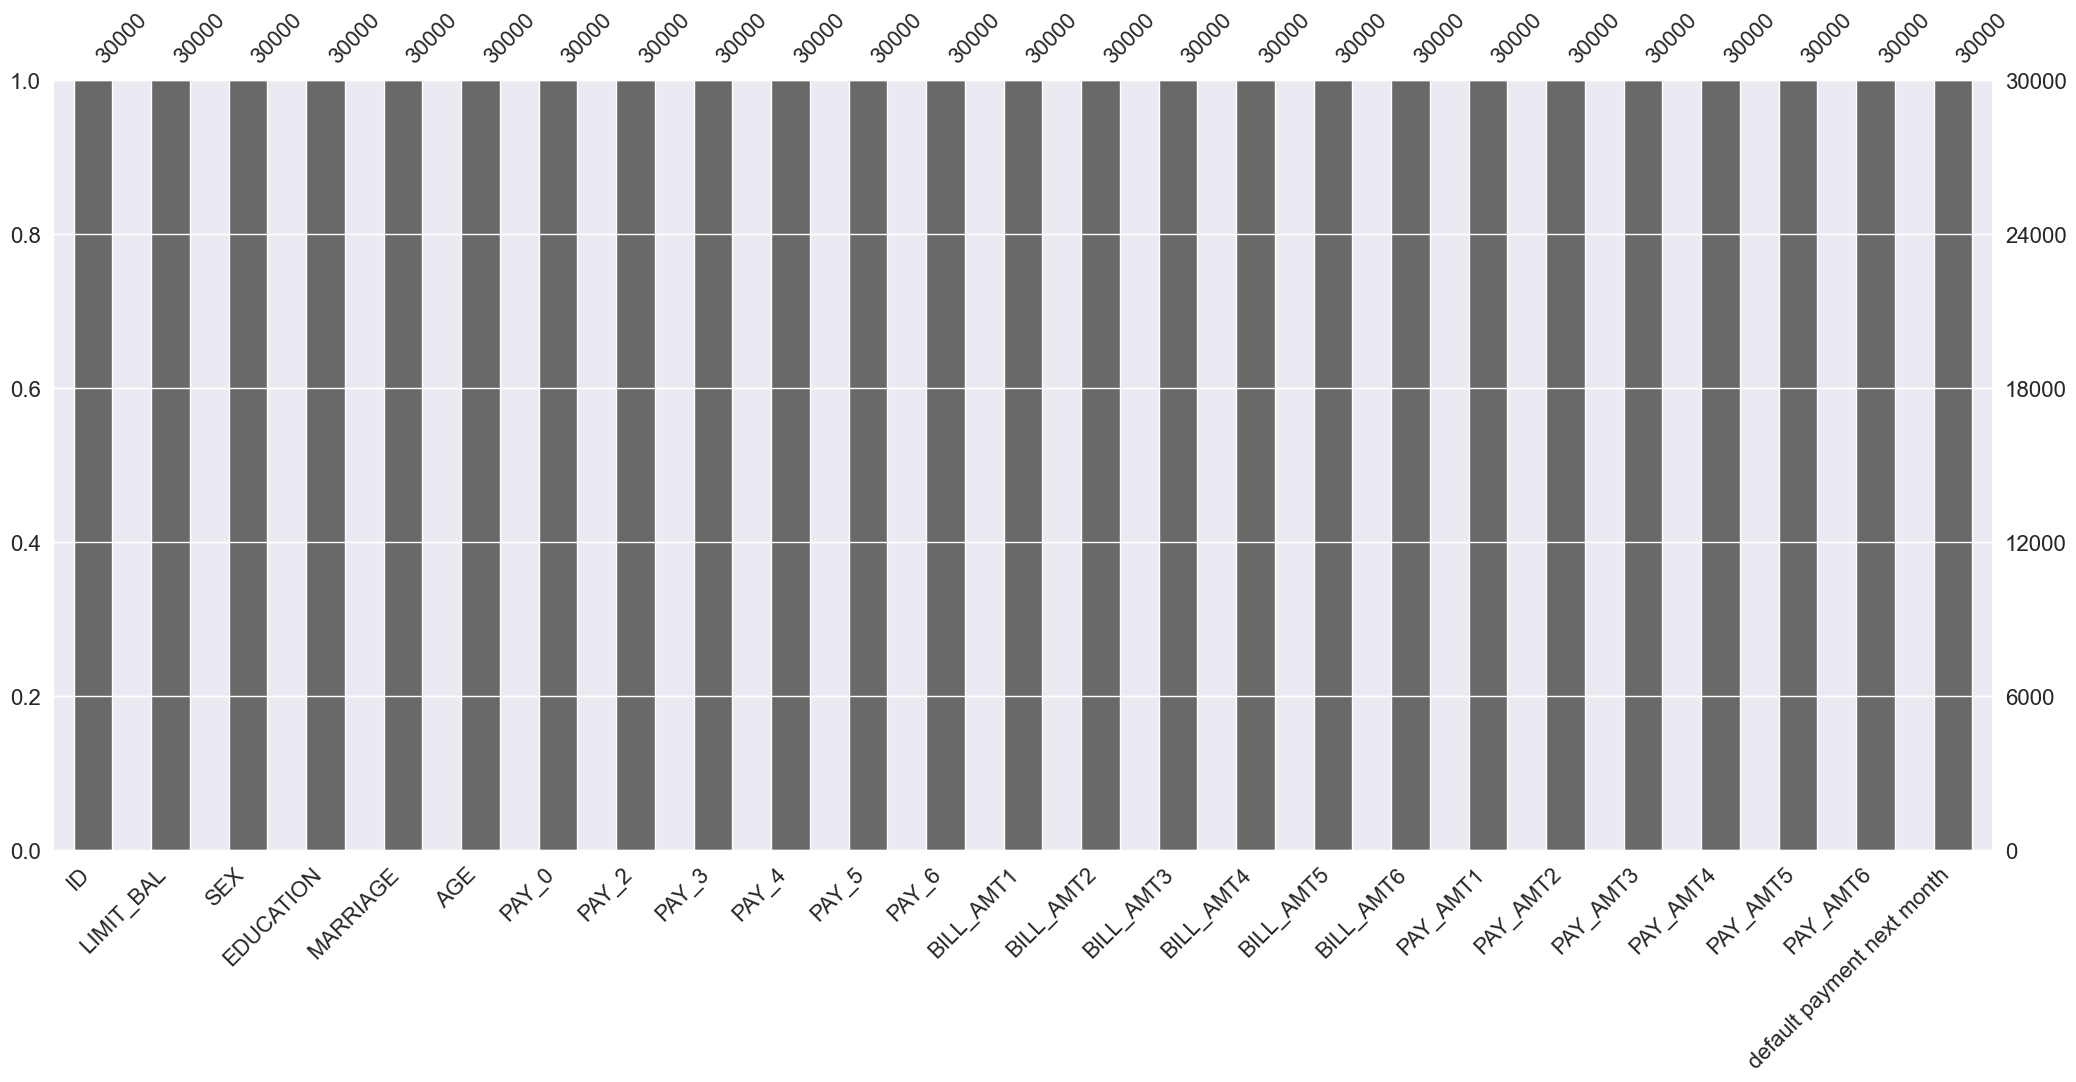

In [88]:
msno.bar(df);

In [89]:
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [90]:
df.rename(columns={'default payment next month':'default'}, inplace=True)
default = pd.DataFrame()
default['debt'] = df['LIMIT_BAL']
default['income'] = df[['BILL_AMT1','BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
default['default_status'] = df['default']
default[default['default_status'] == 1]
default_labeled = copy.copy(default)
default_labeled['default_status'] = default_labeled['default_status'].apply(lambda x: 'paid' if x == 0 else 'defaulted')
default_labeled

,debt,income,default_status
0,20000,7704,defaulted
1,120000,17077,defaulted
2,90000,101653,paid
3,50000,231334,paid
4,50000,109339,paid
...,...,...,...
29995,220000,725349,paid
29996,150000,21182,paid
29997,30000,70496,defaulted
29998,80000,266611,defaulted


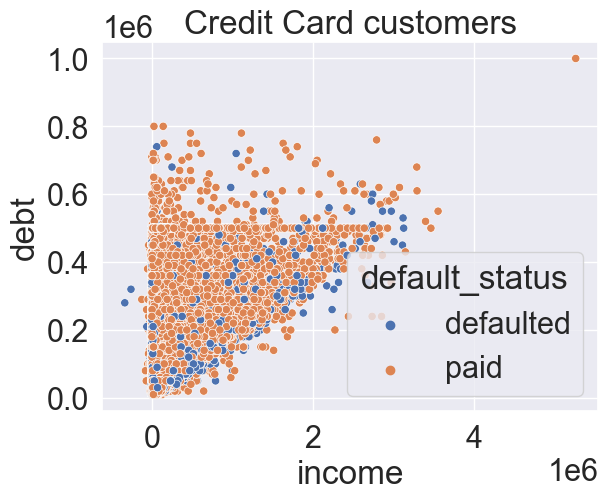

In [91]:
sns.scatterplot(data = default_labeled, x='income', y='debt', hue='default_status')
plt.title('Credit Card customers')
plt.show()

In [92]:
default['default_status'].value_counts()

0    23364
1     6636
Name: default_status, dtype: int64

In [93]:
x_range = np.linspace(0, 5500000, 100000)
min(default['income']), max(default['income'])

(-336259, 5263883)

In [94]:
y_range = np.linspace(0, 1000000, 100000)
min(default['debt']), max(default['debt'])

(10000, 1000000)

In [95]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(default.drop('default_status', axis = 1), default.default_status, test_size=0.50,random_state=42, stratify = default.default_status)
base_pipe = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
base_pipe.fit(X_train_base, y_train_base)
base_acc = base_pipe.score(X_test_base, y_test_base)
preds = base_pipe.predict(X_test_base)
base_acc

0.7417333333333334

In [96]:
print('Classification Report for credit limit default.')
print('-----------------------------------------------------')
print(classification_report(y_test_base, preds))

Classification Report for credit limit default.
-----------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.91      0.85     11682
           1       0.32      0.15      0.21      3318

    accuracy                           0.74     15000
   macro avg       0.56      0.53      0.53     15000
weighted avg       0.69      0.74      0.70     15000


In [97]:
test_predictions = base_pipe.predict_proba(X_test_base)

In [98]:
def precision_thresh(predict_probs, y_test, thresh):
    preds = np.where(predict_probs >= thresh, 1, 0)
    return precision_score(y_test, preds, pos_label=1)

In [99]:
print(precision_thresh(test_predictions[:, 1], y_test_base, 0.1))
print(precision_thresh(test_predictions[:, 1], y_test_base, 0.9))

0.24548192771084337
0.36363636363636365


In [100]:
thresholds = np.arange(0, 1, 0.1)
results_df = pd.DataFrame({'threshold': thresholds, 'precision': [precision_thresh(test_predictions[:, 1], y_test_base, i) for i in thresholds]})

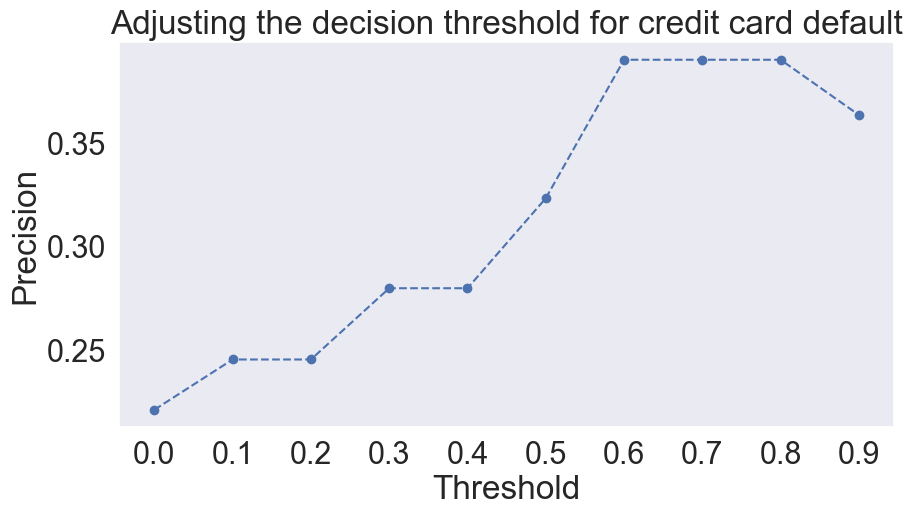

In [101]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(results_df['threshold'], results_df['precision'], '--o', label = 'precision')
plt.xticks(thresholds)
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.grid();
plt.title('Adjusting the decision threshold for credit card default');
plt.show()

In [102]:
def recall_thresh(predict_probs, y_test, thresh):
    preds = np.where(predict_probs >= thresh, 1, 0)
    return recall_score(y_test, preds, pos_label=1)

results_df['recall'] = [recall_thresh(test_predictions[:, 1], y_test_base, i) for i in thresholds]

In [103]:
print(recall_thresh(test_predictions[:, 1], y_test_base, 0.1))
print(recall_thresh(test_predictions[:, 1], y_test_base, 0.9))
results_df

0.7368896925858951
0.0024110910186859553


,threshold,precision,recall
0,0.0,0.221200,1.000000
1,0.1,0.245482,0.736890
2,0.2,0.245482,0.736890
3,0.3,0.279923,0.395419
4,0.4,0.279923,0.395419
5,0.5,0.323380,0.153406
6,0.6,0.390323,0.036468
7,0.7,0.390323,0.036468
8,0.8,0.390323,0.036468
9,0.9,0.363636,0.002411


[0.  0.2 0.4 0.6 0.8]


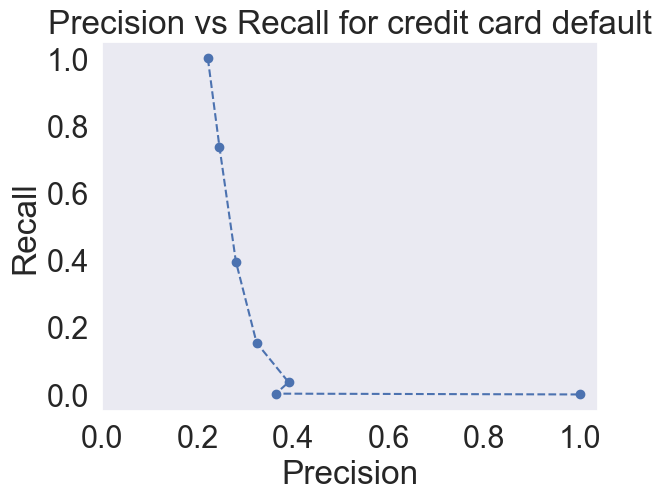

In [104]:
precision, recall, boundaries = precision_recall_curve(y_test_base, test_predictions[:, 1], pos_label=1)

# Answer check
print(boundaries[:5])
plt.plot(precision, recall, '--o')
plt.xticks(boundaries);
plt.grid()
plt.ylabel('Recall')
plt.xlabel('Precision')
plt.title('Precision vs Recall for credit card default');

In [105]:
boundaries[:4]

array([0. , 0.2, 0.4, 0.6])

In [106]:
y_train_base.value_counts(normalize = True)

0    0.7788
1    0.2212
Name: default_status, dtype: float64

In [107]:
min_fp = precision_score(y_test_base, base_pipe.predict(X_test_base), pos_label = 0)
min_fp

0.7907790853567704

In [108]:
base_probs = base_pipe.predict_proba(X_test_base)
base_probs

array([[1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       ...,
       [1. , 0. ],
       [1. , 0. ],
       [0.8, 0.2]])

In [109]:
def get_misclassification_rate_for_k(k):
    parameters_to_try = {'knn__n_neighbors': [k]}
    knn_pipe = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
    knn_grid = GridSearchCV(estimator = knn_pipe, param_grid = parameters_to_try)
    knn_grid.fit(default[['income','debt']], default['default_status'])
    return 1 - accuracy_score(knn_grid.predict(default[['income','debt']]), default['default_status'])

In [110]:
ks = range(1, 100)
errors = [get_misclassification_rate_for_k(k) for k in ks]
errors_and_ks = pd.DataFrame({'k': ks, 'Misclassification Rate': errors})
errors_and_ks["-k"] = -errors_and_ks["k"]

In [111]:
fig = px.line(errors_and_ks, x = "-k", y = "Misclassification Rate")
standardize_figure(fig)
fig.show()

### predict_proba - Model, k = 10

In [112]:
default_pred = copy.copy(default)
model = KNeighborsClassifier(n_neighbors = 10)
model.fit(default[['income', 'debt']], default['default_status'])

KNeighborsClassifier(n_neighbors=10)

In [113]:
ten_random_rows = default[["income", "debt"]].sample(100)
#ten_random_rows = default_pred[["income", "debt"]].iloc[[217, 70, 146, 211, 71, 23, 179, 163, 144, 157]]
ten_random_rows

,income,debt
10826,0,120000
19437,761726,200000
11858,39476,360000
12013,147025,80000
9196,22948,170000
...,...,...
22816,679705,260000
13953,833412,370000
20969,7232,360000
16963,349862,110000


In [114]:
pd.DataFrame(model.predict(ten_random_rows[["income", "debt"]]), columns = ["prediction"])

,prediction
0,0
1,0
2,0
3,0
4,0
...,...
95,0
96,0
97,0
98,0


In [115]:
model.predict_proba(ten_random_rows[["income", "debt"]])

array([[0.5, 0.5],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.6, 0.4],
       [0.5, 0.5],
       [0.8, 0.2],
       [1. , 0. ],
       [0.8, 0.2],
       [1. , 0. ],
       [1. , 0. ],
       [0.7, 0.3],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.9, 0.1],
       [0.4, 0.6],
       [0.8, 0.2],
       [0.4, 0.6],
       [0.7, 0.3],
       [0.6, 0.4],
       [1. , 0. ],
       [0.7, 0.3],
       [0.9, 0.1],
       [0.6, 0.4],
       [0.5, 0.5],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.9, 0.1],
       [0.6, 0.4],
       [0.6, 0.4],
       [1. , 0. ],
       [0.9, 0.1],
       [0.8, 0.2],
       [0.9, 0.1],
       [0.9, 0.1],
       [0.2, 0.8],
       [0.6, 0.4],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.7, 0.3],
       [0.6, 0.4],
       [0.9, 0.1],
       [0.8, 0.2],
       [0.7, 0.3],
       [0.7, 0.3],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.8, 0.2],
       [0.9, 0.1],
       [0.9,

In [116]:
pd.DataFrame([0 if 0 else 1 for x in model.predict_proba(ten_random_rows[["income", "debt"]])[:, 1] >= 0.9], columns = ["prediction"])

,prediction
0,1
1,1
2,1
3,1
4,1
...,...
95,1
96,1
97,1
98,1


### Precision Recall Curves

In [117]:
def show_confusion_matrix_and_print_accuracy_and_recall(reality, predictions):
    cm = confusion_matrix(reality, predictions)
    sns.heatmap(cm, annot=True, fmt = "d", cmap = "Blues", annot_kws={"size": 50}, cbar = False)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    sns.set(font_scale = 2)
    print(f"Precision: {precision_score(reality, predictions)}")
    print(f"Recall: {recall_score(reality, predictions)}")

In [118]:
def predict_with_threshold(probabilities, T):
    p1 = probabilities[:, 1]
    return 1 * (p1 > T)

In [119]:
model = KNeighborsClassifier(n_neighbors = 66)
model.fit(default[['income', 'debt']], default['default_status'])

model
#print(classification_report(default[['income', 'debt']], pred_default, target_names=default['default_status']))

KNeighborsClassifier(n_neighbors=66)

In [120]:
pred_default = model.predict(default[['income', 'debt']])

In [121]:
yhat_probabilities = model.predict_proba(default[['income', 'debt']])

In [122]:
default["status_number"] = (default["default_status"] == 0) * 1

Precision: 0.7014123611781748
Recall: 0.49738914569423043


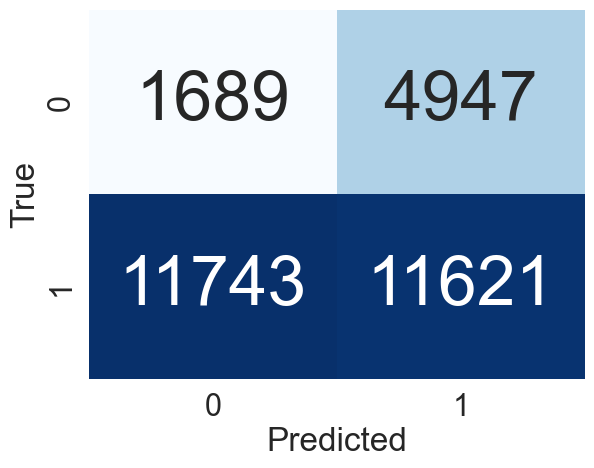

In [123]:
show_confusion_matrix_and_print_accuracy_and_recall(default["status_number"], predict_with_threshold(yhat_probabilities, 0.2))

Precision: 0.5483359746434231
Recall: 0.029618216058894024


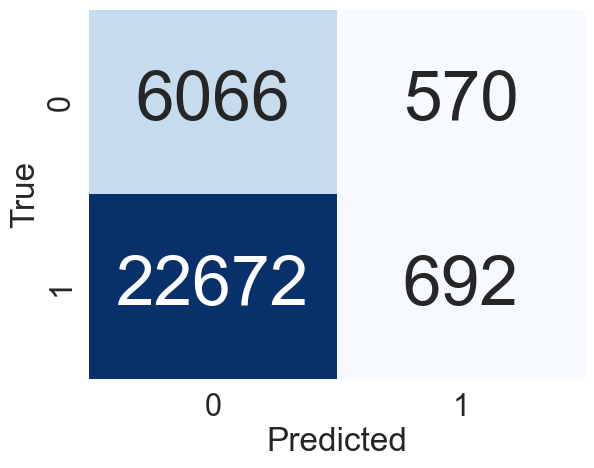

In [124]:
show_confusion_matrix_and_print_accuracy_and_recall(default["status_number"], predict_with_threshold(yhat_probabilities, 0.4))

Precision: 1.0
Recall: 4.2800890258517374e-05


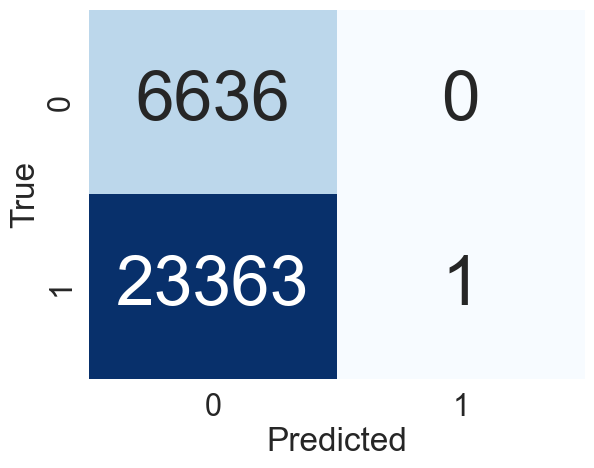

In [125]:
show_confusion_matrix_and_print_accuracy_and_recall(default["status_number"], predict_with_threshold(yhat_probabilities, 0.6))

Precision: 0.0
Recall: 0.0


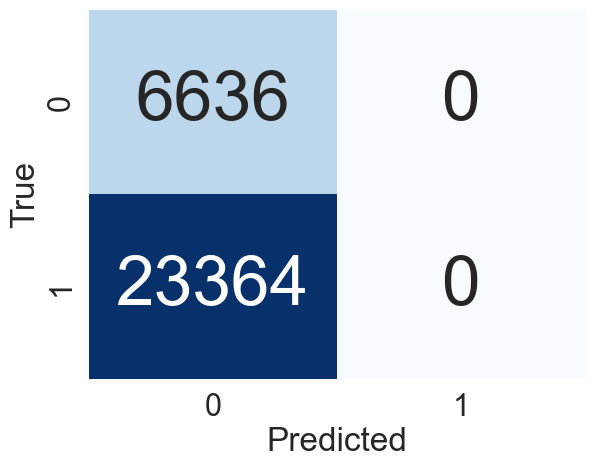

In [126]:
show_confusion_matrix_and_print_accuracy_and_recall(default["status_number"], predict_with_threshold(yhat_probabilities, 0.7))

In [127]:
precision, recall, thresholds = precision_recall_curve(default["default_status"], yhat_probabilities[:, 1], pos_label = 0)

precision_recall_data = pd.DataFrame({"precision" : precision[:-1], "recall": recall[:-1], "T": thresholds})
fig = px.line(precision_recall_data, y = "precision", x = "recall", hover_name = "T", markers = True)
standardize_figure(fig)
fig.update_layout(legend_title= "", legend=dict(x=0.05, y=0.05, bordercolor="White", borderwidth=2))
fig.show()

In [128]:
# acc_map = {}
# roc_map = {}
# for i in range(1, 51):
#     parameters_to_try_acc = {'knn__n_neighbors': [i]}
#     knn_pipe_acc = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
#     knn_grid_acc = GridSearchCV(knn_pipe_acc, param_grid = parameters_to_try_acc, scoring = "accuracy", cv = 5)
#     knn_grid_acc.fit(df.drop('default', axis = 1), df["default"])
#     acc_map[i] = list(knn_grid_acc.best_params_.values())[0]
#     knn_grid_acc.best_estimator_
# 
#     parameters_to_try_roc = {'knn__n_neighbors': [i]}
#     knn_pipe_roc = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
#     knn_grid_roc = GridSearchCV(knn_pipe_roc, param_grid = parameters_to_try_roc, scoring = 'roc_auc')
#     knn_grid_roc.fit(df.drop('default', axis = 1), df["default"])
#     roc_map[i] = list(knn_grid_roc.best_params_.values())[0]
#     knn_grid_roc.best_estimator_

In [129]:
X_train, X_test, y_train, y_test = train_test_split(default.drop('default_status', axis = 1), default.default_status, test_size=0.50, random_state=42, stratify = default.default_status)


### Accuracy scoring

In [130]:
parameters_to_try_acc = {'knn__n_neighbors': np.array(range(1, 100))}
knn_pipe_acc = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
knn_grid_acc = GridSearchCV(estimator = knn_pipe_acc, param_grid = parameters_to_try_acc, scoring = "accuracy", cv = 5)
knn_grid_acc.fit(X_train, y_train)
print(list(knn_grid_acc.best_params_.values())[0])
knn_grid_acc

1


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler',
                                        StandardScaler(with_mean=False)),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])},
             scoring='accuracy')

In [131]:
knn_grid_acc.best_estimator_

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('knn', KNeighborsClassifier(n_neighbors=1))])

In [132]:
preds_accuracy = knn_grid_acc.predict(X_test)
preds_accuracy

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [133]:
gridsearch_output = pd.DataFrame({'CV accuracy': knn_grid_acc.cv_results_['mean_test_score'], 'k': np.array(range(1, 100))})

In [134]:
gridsearch_output["-k"] = -gridsearch_output["k"]
gridsearch_output["CV Error"] = 1 - gridsearch_output["CV accuracy"]

In [135]:
fig = px.line(gridsearch_output, x = "-k", y = "CV Error")
standardize_figure(fig)
fig.show()

In [136]:
both_training_and_CV_errors = pd.merge(errors_and_ks.rename(columns = {"Misclassification Rate": "Training Error"}),
                                       gridsearch_output,
                                       left_on = "-k",
                                       right_on = "-k",
                                       how = "inner")
both_training_and_CV_errors

,k_x,Training Error,-k,CV accuracy,k_y,CV Error
0,1,0.015100,-1,1.000000,1,0.000000
1,2,0.164367,-2,1.000000,2,0.000000
2,3,0.164933,-3,1.000000,3,0.000000
3,4,0.193600,-4,1.000000,4,0.000000
4,5,0.195333,-5,1.000000,5,0.000000
...,...,...,...,...,...,...
94,95,0.220900,-95,0.999067,95,0.000933
95,96,0.220867,-96,0.999067,96,0.000933
96,97,0.220933,-97,0.999067,97,0.000933
97,98,0.220867,-98,0.999067,98,0.000933


In [137]:
fig = px.line(both_training_and_CV_errors, x = "-k", y = ["Training Error", "CV Error"])
standardize_figure(fig)
fig.update_layout(legend_title= "", legend=dict( x=0.05, y=0.05, bordercolor="Black", borderwidth=2))
fig.show()

In [138]:
fig = px.line(both_training_and_CV_errors.iloc[0:15], x = "-k", y = ["Training Error", "CV Error"])
standardize_figure(fig)
fig.update_layout(legend_title= "", legend=dict(x=0.05, y=0.05, bordercolor="Black", borderwidth=2))
fig.show()

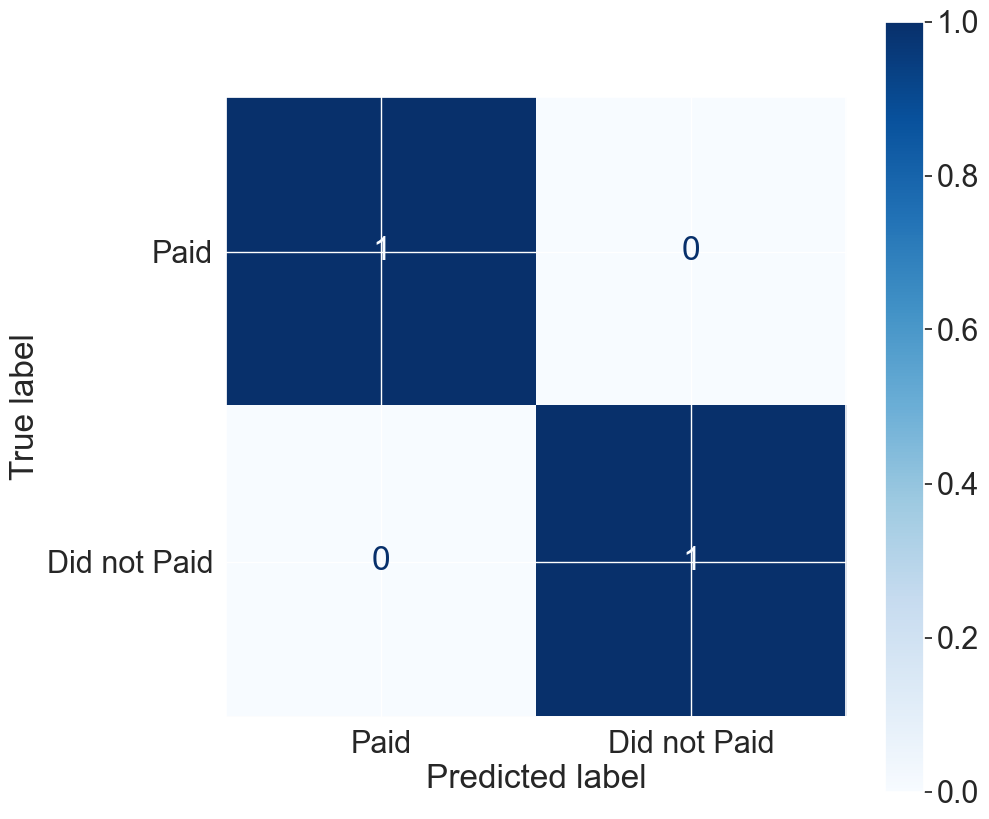

In [139]:
default_confusion_mat_acc = confusion_matrix(y_test, preds_accuracy, labels=[1, 0], normalize='true')
disp_acc = ConfusionMatrixDisplay(confusion_matrix=default_confusion_mat_acc, display_labels=['Paid', 'Did not Paid' ])
fig, ax = plt.subplots(figsize=(10,10))
disp_acc.plot(ax=ax, cmap=plt.cm.Blues)
plt.show()

Precision: 1.0
Recall: 1.0


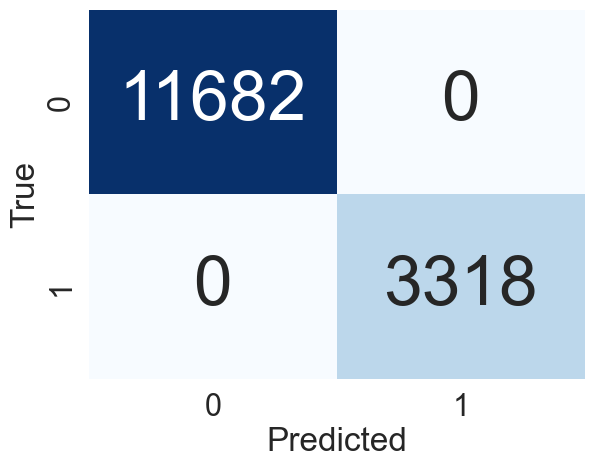

In [140]:
show_confusion_matrix_and_print_accuracy_and_recall(y_test, preds_accuracy,)

### Recall scoring

In [141]:
parameters_to_try_rec = {'knn__n_neighbors': [1]}
knn_pipe_rec = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
knn_grid_rec = GridSearchCV(estimator = knn_pipe_rec, param_grid = parameters_to_try_rec, scoring = 'recall')
#knn_grid_rec.fit(df.drop('default', axis = 1), df["default"])
knn_grid_rec.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler',
                                        StandardScaler(with_mean=False)),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1]}, scoring='recall')

In [142]:
preds_recall = knn_grid_rec.predict(X_test)
preds_recall

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [143]:
best_score = knn_grid_rec.score(X_test, y_test)
print(f'The best recall score is: {best_score: .2f}')

The best recall score is:  1.00


In [144]:
knn_grid_rec.best_estimator_

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('knn', KNeighborsClassifier(n_neighbors=1))])

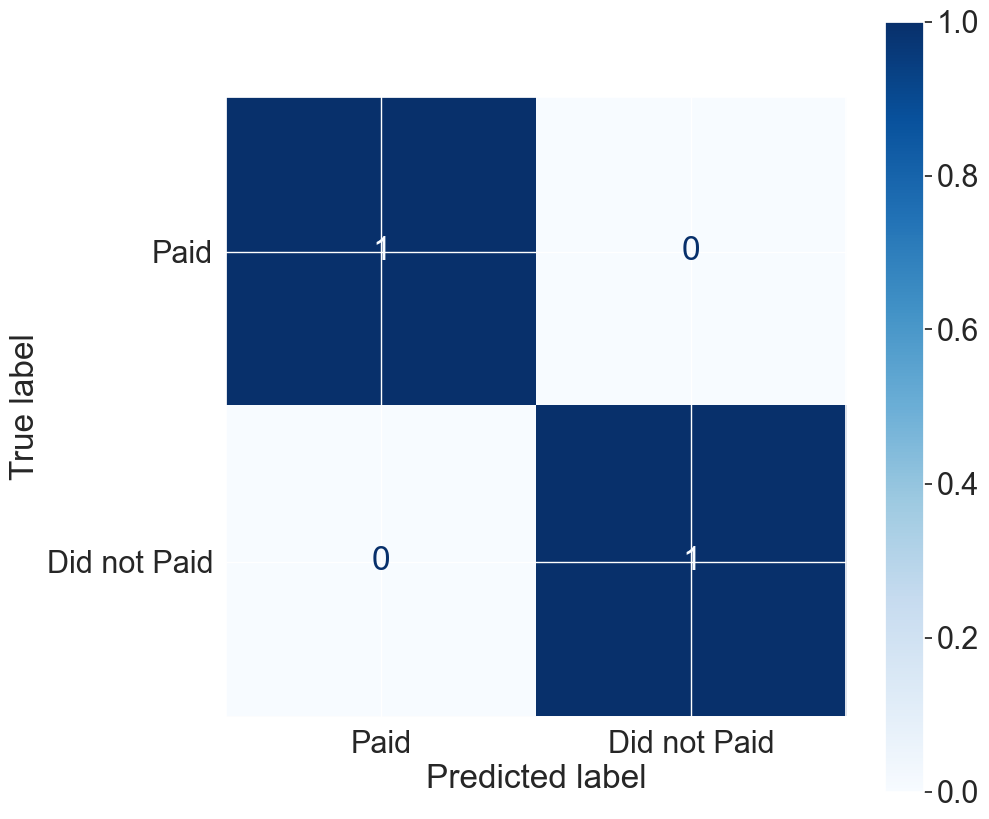

In [145]:
default_confusion_mat_rec = confusion_matrix(y_test, preds_recall, labels=[1, 0], normalize='true')
disp_rec = ConfusionMatrixDisplay(confusion_matrix=default_confusion_mat_rec, display_labels=['Paid', 'Did not Paid' ])
fig, ax = plt.subplots(figsize=(10,10))
disp_rec.plot(ax=ax, cmap=plt.cm.Blues)
plt.show()

Precision: 1.0
Recall: 1.0


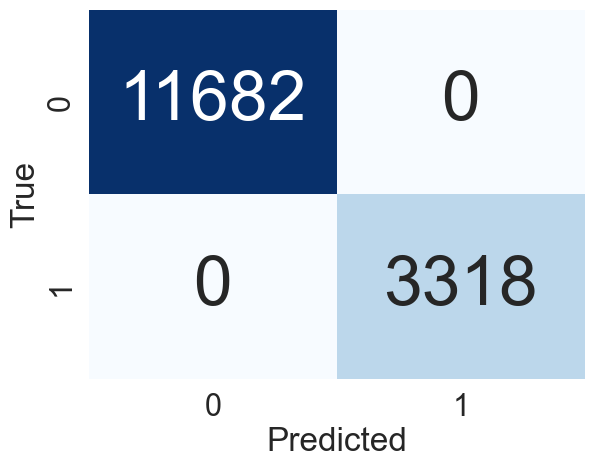

In [146]:
show_confusion_matrix_and_print_accuracy_and_recall(y_test, preds_recall,)

### ROC_AUC scoring

In [147]:
parameters_to_try_roc = {'knn__n_neighbors': [49]}
knn_pipe_roc = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier())])
knn_grid_roc = GridSearchCV(estimator = knn_pipe_roc, param_grid = parameters_to_try_roc, scoring = 'roc_auc')
knn_grid_roc.fit(X_train, y_train)
knn_grid_roc

GridSearchCV(estimator=Pipeline(steps=[('scaler',
                                        StandardScaler(with_mean=False)),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [49]}, scoring='roc_auc')

In [148]:
preds_roc_auc = knn_grid_rec.predict(X_test)
preds_roc_auc

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

In [149]:
best_score_roc = knn_grid_roc.score(X_test, y_test)
print(f'The best roc_auc score is: {best_score_roc: .2f}')

The best roc_auc score is:  1.00


In [150]:
test_predictions = knn_grid_roc.predict_proba(X_test)

In [151]:
test_predictions

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [0., 1.]])

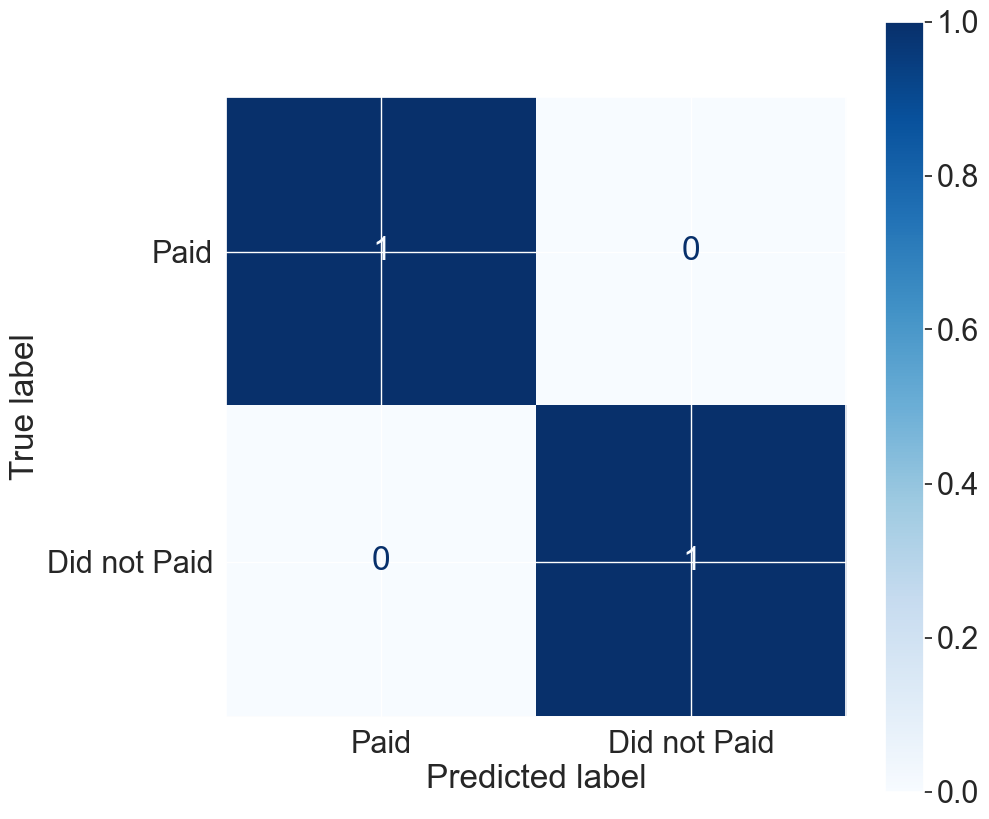

In [152]:
default_confusion_mat_roc = confusion_matrix(y_test, preds_roc_auc, labels=[1, 0], normalize='true')
disp_roc = ConfusionMatrixDisplay(confusion_matrix=default_confusion_mat_roc, display_labels=['Paid', 'Did not Paid' ])
fig, ax = plt.subplots(figsize=(10,10))
disp_roc.plot(ax=ax, cmap=plt.cm.Blues)
plt.show()

Precision: 1.0
Recall: 1.0


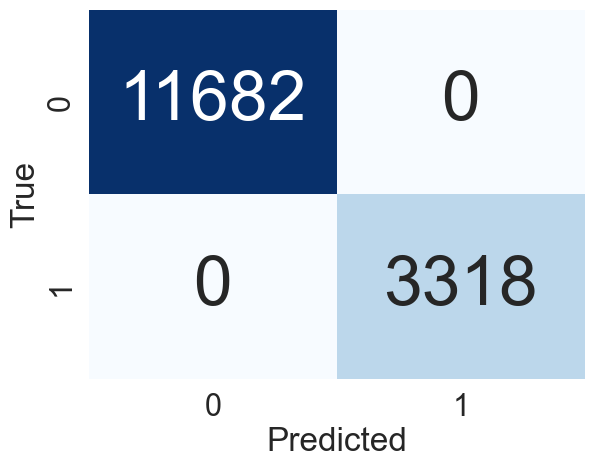

In [153]:
show_confusion_matrix_and_print_accuracy_and_recall(y_test, preds_roc_auc)

In [154]:
print(classification_report(y_test, preds_roc_auc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11682
           1       1.00      1.00      1.00      3318

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


In [155]:
knn_1 = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier(n_neighbors = 1))])
knn_1.fit(X_train_base, y_train_base)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('knn', KNeighborsClassifier(n_neighbors=1))])

In [156]:
knn_pipe = Pipeline([('scaler', StandardScaler(with_mean=False)), ('knn', KNeighborsClassifier(n_neighbors = 10))])
knn_pipe.fit(X_train_base, y_train_base)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('knn', KNeighborsClassifier(n_neighbors=10))])

In [157]:
roc_grid = GridSearchCV(knn_pipe, param_grid={'knn__n_neighbors': range(1, 60, 2)}, scoring = 'roc_auc')
roc_grid.fit(X_train_base, y_train_base)
best_k = roc_grid.best_params_['knn__n_neighbors']

In [158]:
best_k

55

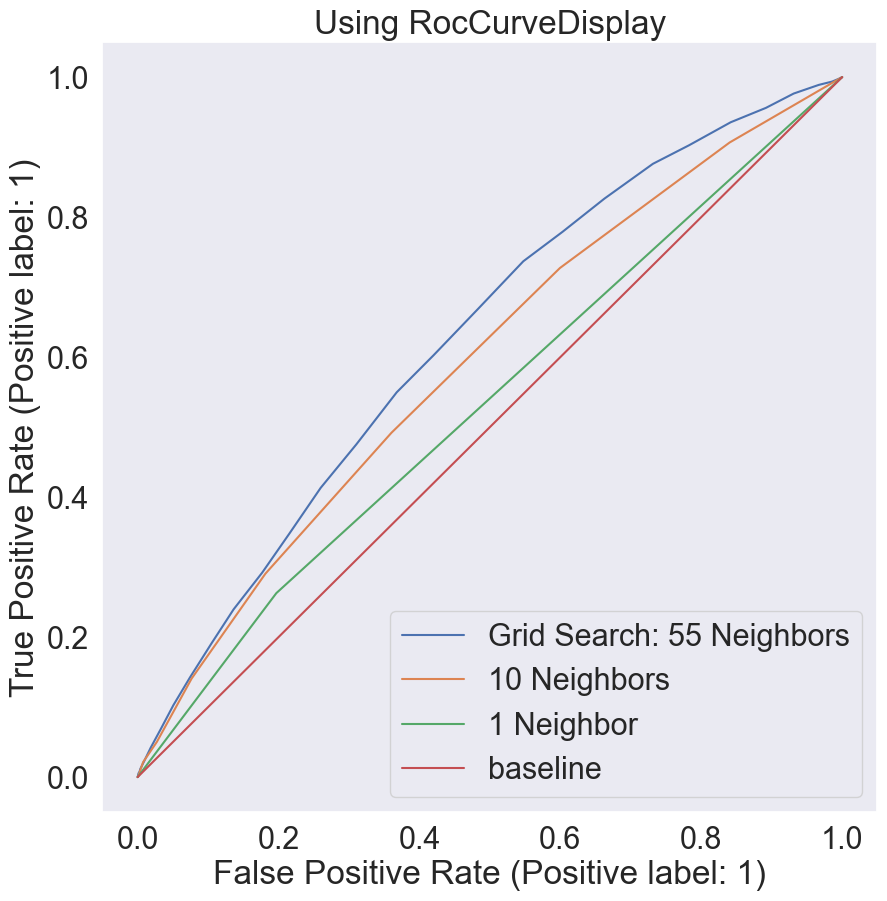

In [159]:
fig, ax = plt.subplots(figsize=(10,10))
RocCurveDisplay.from_estimator(roc_grid, X_test_base, y_test_base, pos_label = 1, ax = ax, label = 'Grid Search: 55 Neighbors')
RocCurveDisplay.from_estimator(knn_pipe, X_test_base, y_test_base, pos_label = 1, ax = ax, label = '10 Neighbors')
RocCurveDisplay.from_estimator(knn_1, X_test_base, y_test_base, ax = ax, label = '1 Neighbor')
plt.grid()
plt.plot(np.arange(0, 1.1, .1), np.arange(0, 1.1, .1), label = 'baseline');
plt.title('Using RocCurveDisplay')
plt.legend();

### Nearest Neighbors for Regression

Text(0.5, 1.0, 'Credit Card customers')

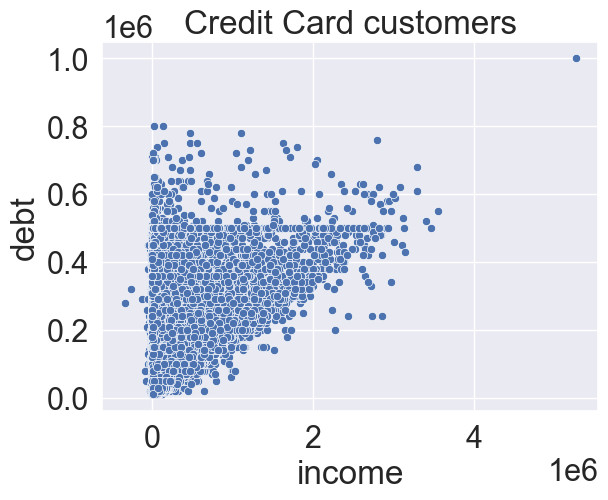

In [160]:
sns.scatterplot(data=default, x="income", y="debt")
fig = plt.gcf()
plt.title('Credit Card customers')

In [165]:
rmodel = KNeighborsRegressor(n_neighbors = 1)
rmodel.fit(default[["income"]], default["debt"])
rmodel.predict([[158000]])

array([210000.])

In [166]:
rmodel

KNeighborsRegressor(n_neighbors=1)

MSE: 0.30273333333333335
MSE: 0.0


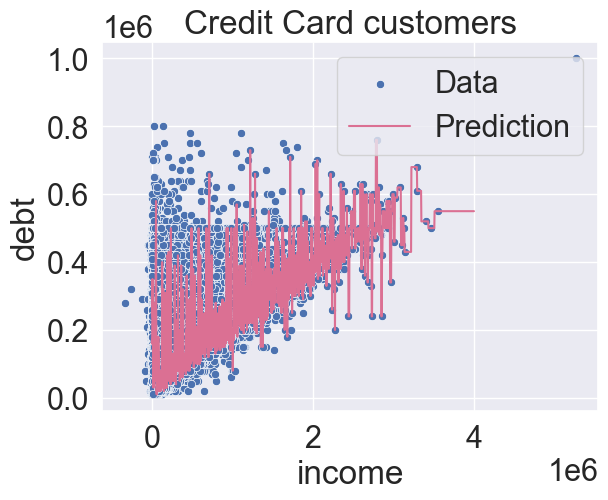

In [168]:
income_values = np.linspace(0, 4000000, 1000)
sns.scatterplot(data=default, x="income", y="debt")
sns.lineplot(x = income_values, y = rmodel.predict(income_values.reshape(-1, 1)), color="palevioletred")
plt.legend(['Data', 'Prediction'])
fig = plt.gcf()
plt.title('Credit Card customers')
fig.show()
rmodel.fit(X_train, y_train)
print(f"MSE: {mean_squared_error(y_test, rmodel.predict(X_test))}")
print(f"MSE: {median_absolute_error(y_test, rmodel.predict(X_test))}")

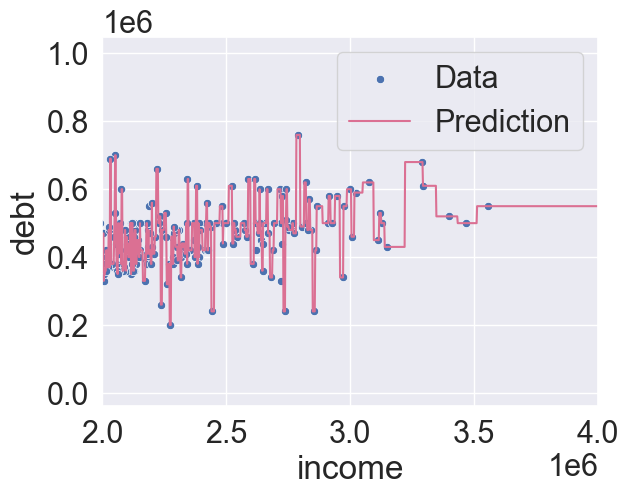

In [170]:
income_values = np.linspace(2000000, 4000000, 1000)
sns.scatterplot(data=default, x="income", y="debt")
rmodel.fit(default[["income"]], default["debt"])
sns.lineplot(x = income_values, y = rmodel.predict(income_values.reshape(-1, 1)), color="palevioletred")
plt.gca().set_xlim(2000000, 4000000)
plt.legend(['Data', 'Prediction'])
fig = plt.gcf()

In [172]:
rmodel50 = KNeighborsRegressor(n_neighbors = 100)
rmodel50.fit(default[["income"]], default["debt"])

KNeighborsRegressor(n_neighbors=100)

MSE: 0.16529528666666665
MSE: 0.24


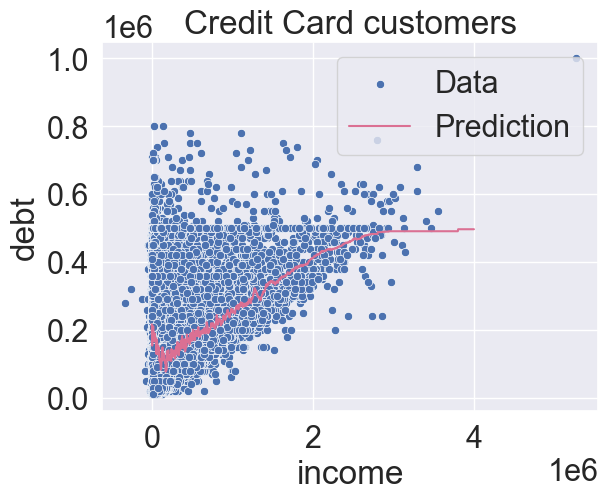

In [173]:
income_values = np.linspace(0, 4000000, 1000)
sns.scatterplot(data=default, x="income", y="debt")
sns.lineplot(x = income_values, y = rmodel50.predict(income_values.reshape(-1, 1)), color="palevioletred")
plt.legend(['Data', 'Prediction'])
plt.title('Credit Card customers')
fig = plt.gcf()
rmodel50.fit(X_train, y_train)
print(f"MSE: {mean_squared_error(y_test, rmodel50.predict(X_test))}")
print(f"MSE: {median_absolute_error(y_test, rmodel50.predict(X_test))}")

In [175]:
rmodel50.fit(default[["income"]], default["debt"])
rmodel50.predict([[158000]])

array([106800.])

In [176]:
rmodel220 = KNeighborsRegressor(n_neighbors = 30000)
rmodel220.fit(default[["income"]], default["debt"])

KNeighborsRegressor(n_neighbors=30000)

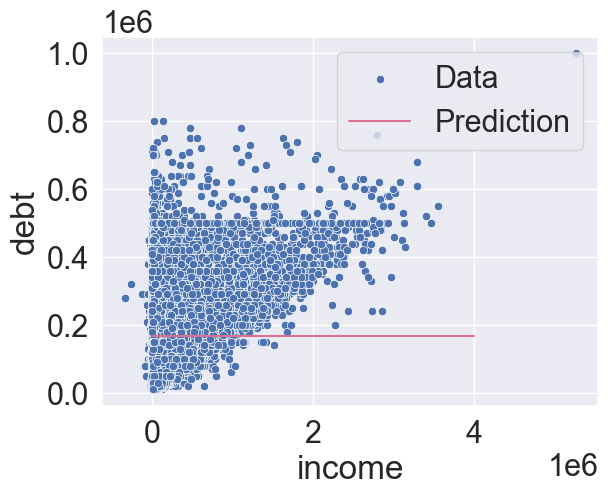

In [182]:
income_values = np.linspace(0, 4000000, 1000)
sns.scatterplot(data=default, x="income", y="debt")
rmodel50.fit(default[["income"]], default["debt"])
sns.lineplot(x = income_values, y = rmodel220.predict(income_values.reshape(-1, 1)), color="palevioletred")
plt.legend(['Data', 'Prediction'])
fig = plt.gcf()
fig.show()

In [178]:
default['default_status'] = np.where(default['default_status'] == 0, 'Paid', 'Did not Paid')

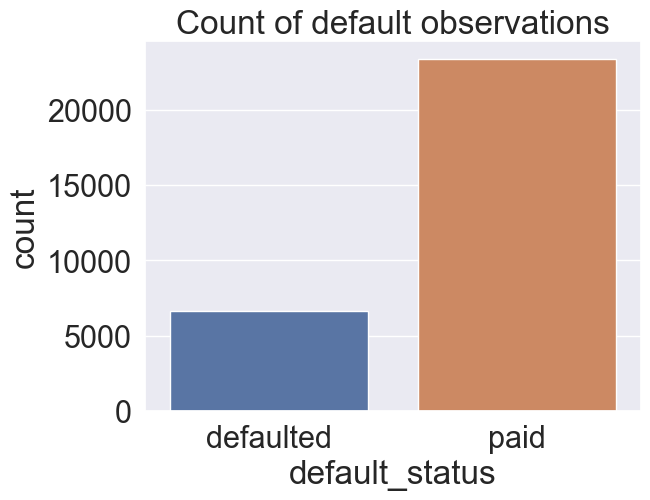

In [179]:
sns.countplot(data=default_labeled, x = 'default_status')
plt.title('Count of default observations');

In [180]:
default['default_status'].value_counts()

Paid            23364
Did not Paid     6636
Name: default_status, dtype: int64

In [181]:
df['default'].value_counts()

0    23364
1     6636
Name: default, dtype: int64